In [1]:
#imports and libraries
import numpy as np
import pandas as pd
import joblib as jl
import sys
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor,RandomForestClassifier
from sklearn.model_selection import cross_val_score,TimeSeriesSplit
from sklearn.metrics import (
    mean_squared_error,
    r2_score,
    classification_report,
    confusion_matrix,
    mean_absolute_error,
    root_mean_squared_error
)
from matplotlib import pyplot as plt
import seaborn as sb

sys.path.append("..")

In [3]:
train=pd.read_csv("../data/processed/trainPool.csv")
test=pd.read_csv("../data/processed/test.csv")

# xTrainScaledSmote=np.load("../data/processed/xtrain_scaled.npy")
# yTrainSeveritySmote=np.load("../data/processed/ytrain_severity.npy")

features = [

    "T2M_mean", "RH2M_mean", "PRECTOTCORR_sum", "WS10M_mean",
    "T2M_lag1", "PRECTOTCORR_lag1", "PRECTOTCORR_lag2",
    "t1_cases", "t2_cases",
    "waterProxy",
    "month_sin", "month_cos",
    "week_sin", "week_cos","isOutbreak"
]
target = "cases"

xTrainPool=train[features]

xTestPool=test[features]
yTrainPool=train[target]

yTestPool=test[target]

In [4]:
# helper function to evaluate the model accuracy for the regressors

def regressorEvaluation(model,xTest,yTest):

    predictions=model.predict(xTest)
    predictionsActual=np.expm1(predictions)
    meanSquareError=mean_squared_error(yTest, predictionsActual)
    r2=r2_score(yTest, predictionsActual)
    rootMeanSquareError=root_mean_squared_error(yTest, predictionsActual)
    meanAbsoluteError=mean_absolute_error(yTest, predictionsActual)
    print("The Model Performance metrics are:")
    print(f"R2 Score: {r2}")
    print(f"Mean Squared Error: {meanSquareError}")
    print(f"Root Mean Squared Error: {rootMeanSquareError}")
    print(f"Mean Absolute Error: {meanAbsoluteError}")

    return {
        "R2_Score": r2,
        "MeanSquaredError": meanSquareError,
        "RootMeanSquaredError": rootMeanSquareError,
        "MeanAbsoluteError": meanAbsoluteError
    }

In [5]:
#Linear Regression as baseline model
from sklearn.preprocessing import StandardScaler


yTrainPoolLog=np.log1p(yTrainPool)
yTestLog=np.log1p(yTestPool)

linearRegression=LinearRegression()

linearRegression.fit(xTrainPool,yTrainPoolLog)

linearEvaluations=regressorEvaluation(linearRegression,xTestPool,yTestPool)

timeCv=TimeSeriesSplit(n_splits=5)
cvScore=cross_val_score(linearRegression,xTrainPool,yTrainPoolLog,cv=timeCv,scoring='r2')

print(f"Cross Validation Average R2 Score: {cvScore.mean():.4f}")
print(f"Cross Validation R2 Scores Std: {cvScore.std():.4f}")
print(f"Mean: {cvScore.mean():.4f} ± {cvScore.std():.4f}")
#jl.dump( linearRegression,"../models/linear_baseline.pkl")

The Model Performance metrics are:
R2 Score: 0.2798903009422109
Mean Squared Error: 8.797034554712717
Root Mean Squared Error: 2.965979527021843
Mean Absolute Error: 2.0456478835822063
Cross Validation Average R2 Score: 0.7038
Cross Validation R2 Scores Std: 0.0713
Mean: 0.7038 ± 0.0713


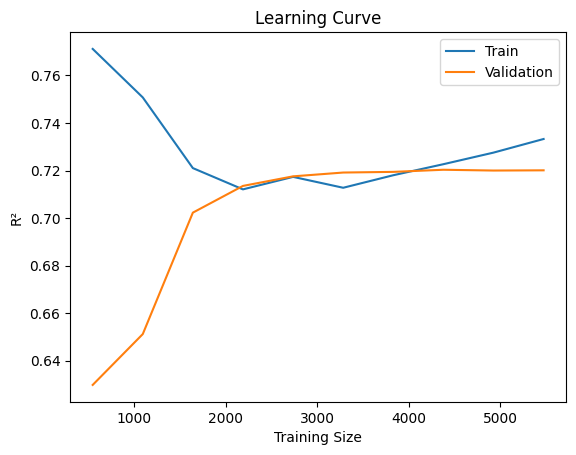

In [7]:
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt

train_sizes, train_scores, test_scores = learning_curve(
    linearRegression, xTrainPool, yTrainPoolLog, cv=5, scoring='r2',
    train_sizes=np.linspace(0.1, 1.0, 10)
)

plt.plot(train_sizes, train_scores.mean(axis=1), label='Train')
plt.plot(train_sizes, test_scores.mean(axis=1),   label='Validation')
plt.xlabel('Training Size')
plt.ylabel('R²')
plt.legend()
plt.title('Learning Curve')
plt.show()

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import cross_val_score, TimeSeriesSplit
from sklearn.metrics import r2_score, root_mean_squared_error
import numpy as np

tsCv = TimeSeriesSplit(n_splits=4)

models = {
    "LinearRegression": LinearRegression(),
    "RandomForest":     RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
    "XGBoost":          XGBRegressor(n_estimators=500, learning_rate=0.01, 
                                     max_depth=4, random_state=42, n_jobs=-1)
}

results = {}

for modelName, model in models.items():
    foldScores = []
    
    for foldNum, (trainIdx, valIdx) in enumerate(tsCv.split(xTrainPool), 1):
        # Slice this fold's data
        xFoldTrain, xFoldVal = xTrainPool.iloc[trainIdx], xTrainPool.iloc[valIdx]
        yFoldTrain, yFoldVal = yTrainPool.iloc[trainIdx], yTrainPool.iloc[valIdx]
        
        # Train and predict
        model.fit(xFoldTrain, yFoldTrain)
        preds = model.predict(xFoldVal)
        
        foldR2   = r2_score(yFoldVal, preds)
        foldRmse = root_mean_squared_error(yFoldVal, preds)
        foldScores.append({"fold": foldNum, "r2": foldR2, "rmse": foldRmse})
        foldmae=mean_absolute_error(yFoldVal,preds)
        foldmse=mean_squared_error(yFoldVal,preds)
        print(f"{modelName} | Fold {foldNum} → R²: {foldR2:.4f}  RMSE: {foldRmse:.2f}")
    
    meanR2   = np.mean([s["r2"]   for s in foldScores])
    meanRmse = np.mean([s["rmse"] for s in foldScores])
    print(f"{modelName} | Mean → R²: {meanR2:.4f}  RMSE: {meanRmse:.2f}\n")
    
    results[modelName] = foldScores

print(results)

The Model Performance metrics are:
R2 Score: 0.40428069642324604
Mean Squared Error: 0.7879814574307434
Root Mean Squared Error: 0.8876831965463486
Mean Absolute Error: 0.5280937588183422
CV R² scores: 0.7419
Mean: 0.7419 ± 0.2289
   district  epi_week  t1_cases  t2_cases
0    attock         1       4.0       5.0
1    attock         2       2.0       4.0
2    attock         3       2.0       2.0
3    attock         4       2.0       2.0
4    attock         5       1.0       2.0
5    attock         6       2.0       1.0
6    attock         7       2.0       2.0
7    attock         8       2.0       2.0
8    attock         9       1.0       2.0
9    attock        10       1.0       1.0
10   attock        11       1.0       1.0
11   attock        12       1.0       1.0
12   attock        13       1.0       1.0
13   attock        14       1.0       1.0
14   attock        15       1.0       1.0
15   attock        16       1.0       1.0
16   attock        18       0.0       1.0
17   attock  

In [39]:
from xgboost import XGBRegressor as xgBoostRegressor


featuresXg = [

    "district_encoded","T2M_mean", "RH2M_mean", "PRECTOTCORR_sum", "WS10M_mean",
    "T2M_lag1", "PRECTOTCORR_lag1", "PRECTOTCORR_lag2",
    "t1_cases", "t2_cases",
    "water_proxy",
    "month_sin", "month_cos",
    "week_sin", "week_cos","isOutbreak"
]
targetXg = "cases"

xTrainScaledXg=train[featuresXg]

xTestScaledXg=test[featuresXg]
yTrainXg=train[targetXg]

yTestXg=test[targetXg]

xgModel = xgBoostRegressor(
    learning_rate=0.01,    # slower learning
    n_estimators=1000,     # more trees to compensate
    max_depth=3,           # keep shallow
    subsample=0.8,         # add some randomness
    colsample_bytree=0.8,  # add some randomness
    min_child_weight=5,    # prevents overfitting on small groups
    random_state=42,
    n_jobs=-1
)

xgModel.fit(xTrainScaledXg, yTrainXg)
xgEvaluation=regressorEvaluation(xgModel, xTestScaledXg, yTestXg)
xgScores = cross_val_score(xgModel, xTrainScaledXg, yTrainXg, cv=tCsv, scoring='r2')
print(f"XGBoost CV R² scores: {xgScores.mean():.4f}")
print(f"Mean: {xgScores.mean():.4f} ± {xgScores.std():.4f}")

The Model Performance metrics are:
R2 Score: 0.41258710622787476
Mean Squared Error: 0.7769942879676819
Root Mean Squared Error: 0.8814727663993835
Mean Absolute Error: 0.5977174639701843
XGBoost CV R² scores: 0.7550
Mean: 0.7550 ± 0.2032
